# 04 - Causal Direction: Populism and Overall Corruption

This notebook tests temporal ordering between governing-party populism and overall political corruption (`v2x_corr`). It builds on the association notebook: the positive pooled relationship does not survive the within-country fixed-effects setup, and the same-year within-country coefficient is small, negative, and fragile.

The strengthened pipeline keeps the original lead-lag and Granger-style models, then adds placebo leads, an event-study around populist-government entry, electoral-sample robustness, first differences, longer lag windows with AIC/BIC, and democracy heterogeneity checks.

Scope note: this notebook uses only the overall corruption index `v2x_corr`; subdimensions belong to the decomposition task.

## 1. Setup

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(ROOT / "src"))

from causal_direction import (
    CORRUPTION,
    POPULISM,
    democracy_interaction_table,
    democracy_split_robustness,
    ensure_panel_lags,
    event_study_results_table,
    fit_corruption_shock_event_study,
    first_difference_results_table,
    fit_democracy_interaction,
    fit_electoral_sample_robustness,
    fit_event_study,
    fit_first_difference_direction,
    fit_granger_style,
    fit_lead_lag,
    fit_placebo_lead_test,
    granger_results_table,
    lag_order_information_criteria,
    lead_lag_results_table,
    panel_autocorrelation,
    placebo_results_table,
    validate_panel,
)
from causal_direction.plots import (
    coefficient_direction_plot,
    democracy_split_plot,
    event_study_plot,
    lag_information_plot,
    placebo_lead_plot,
)

DATA_PATH = ROOT / "data" / "processed" / "panel_populism_corruption.parquet"
TABLE_DIR = ROOT / "docs" / "tables" / "causal-direction"
FIGURE_DIR = ROOT / "docs" / "figures" / "causal-direction"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

controls = ("log_gdppc", "v2x_polyarchy")

## 2. Load and validate the panel

The panel is one row per country-year. `log_gdppc` and `v2x_polyarchy` are included as time-varying confounder controls: economic development and electoral democracy can change within a country over time and plausibly affect both the probability of populist government and measured corruption. Country fixed effects remove stable country differences; year fixed effects remove global shocks; these controls address remaining within-country changes.

In [2]:
df = pd.read_parquet(DATA_PATH)
validation = validate_panel(df)
validation

{'n_rows': 3965,
 'n_countries': 96,
 'min_year': 1970,
 'max_year': 2019,
 'duplicates': 0,
 'internal_year_gaps': 0}

In [3]:
df = ensure_panel_lags(df, lags=(1, 2, 3, 4, 5), leads=(1, 2))
core_vars = (POPULISM, CORRUPTION, "log_gdppc", "v2x_polyarchy", "years_since_last_election")
df[["country_id", "year", POPULISM, CORRUPTION, "log_gdppc", "v2x_polyarchy"]].head()

,country_id,year,populism_governing,v2x_corr,log_gdppc,v2x_polyarchy
0,3,1970,0.199,0.82,2.784208,0.248
1,3,1971,0.199,0.82,2.814150,0.247
2,3,1972,0.199,0.82,2.856643,0.249
3,3,1973,0.196,0.82,2.902630,0.248
4,3,1974,0.196,0.82,2.945649,0.249


## 3. Persistence diagnostics

The autocorrelation checks motivate the Granger-style models. They are kept as scalar diagnostics in the notebook, not as descriptive tables, because coverage and variable-description tables belong to the earlier data/EDA task.

In [4]:
pop_autocorr_lag1 = panel_autocorrelation(df, POPULISM, 1)
pop_autocorr_lag2 = panel_autocorrelation(df, POPULISM, 2)
corr_autocorr_lag1 = panel_autocorrelation(df, CORRUPTION, 1)
corr_autocorr_lag2 = panel_autocorrelation(df, CORRUPTION, 2)

print(f"{POPULISM}: lag-1 autocorr = {pop_autocorr_lag1:.3f}; lag-2 autocorr = {pop_autocorr_lag2:.3f}")
print(f"{CORRUPTION}: lag-1 autocorr = {corr_autocorr_lag1:.3f}; lag-2 autocorr = {corr_autocorr_lag2:.3f}")

populism_governing: lag-1 autocorr = 0.929; lag-2 autocorr = 0.860
v2x_corr: lag-1 autocorr = 0.993; lag-2 autocorr = 0.984


## 4. Lead-lag fixed-effects models

- **Direction A** asks whether past governing populism predicts current corruption. 

- **Direction B** asks whether past corruption predicts current governing populism. 

These are temporal association models with country and year fixed effects, not definitive causal models.

In [5]:
lead_fits = []
for suffix, model_controls in [("controlled", controls), ("no_controls", ())]:
    for lag in [1, 2, 3]:
        for direction in ["populism_to_corruption", "corruption_to_populism"]:
            fit = fit_lead_lag(df, direction=direction, lag_order=lag, controls=model_controls)
            fit.model_id = f"lead_lag_{direction}_L{lag}_{suffix}"
            lead_fits.append(fit)

for direction in ["populism_to_corruption", "corruption_to_populism"]:
    fit = fit_lead_lag(
        df,
        direction=direction,
        lag_order=2,
        controls=controls,
        max_years_since_election=10,
    )
    fit.model_id = f"lead_lag_{direction}_L2_ffill_le10"
    lead_fits.append(fit)

lead_lag = lead_lag_results_table(lead_fits)
main_lead_lag = lead_lag[lead_lag["model"].str.endswith("L2_controlled")]
main_lead_lag[["direction", "coef_lag1", "p_lag1", "coef_lag2", "p_lag2", "interpretation"]]

,direction,coef_lag1,p_lag1,coef_lag2,p_lag2,interpretation
2,populism_to_corruption,-0.048283,0.031463,-0.008026,0.679634,Lagged populism predicts lower later corruption
3,corruption_to_populism,-0.066338,0.586850,-0.125872,0.249511,No robust lag coefficient at p < 0.05


## 5. Granger-style fixed-effects models

These stricter models include the dependent variable's own lags. The joint test asks whether the proposed-cause lags add predictive information beyond persistence.

In [6]:
granger_fits = []
for lag in [1, 2]:
    for direction in ["populism_to_corruption", "corruption_to_populism"]:
        fit = fit_granger_style(
            df,
            direction=direction,
            lag_order=lag,
            controls=controls,
        )
        fit.model_id = f"granger_{direction}_L{lag}_controlled"
        granger_fits.append(fit)

granger = granger_results_table(granger_fits)
granger[granger["lag_order"] == 2]

,direction,dependent_variable,proposed_cause,lag_order,joint_test_stat,joint_test_p,joint_df,n_obs,n_countries,controls,interpretation
2,populism_to_corruption,v2x_corr,populism_governing,2,0.753194,0.686193,2,3750,95,"log_gdppc, v2x_polyarchy",do not reject H0
3,corruption_to_populism,populism_governing,v2x_corr,2,2.848314,0.240711,2,3750,95,"log_gdppc, v2x_polyarchy",do not reject H0


## 6. Placebo lead / pre-trend tests in both directions

A placebo lead test adds future values of the proposed cause to a model for the current outcome. Future values cannot causally affect the present. If the placebo leads are significant, the model may be reading pre-existing trends, anticipation, or omitted time-varying confounding.

We run this check in both directions:

- future governing populism in a model for current corruption;
- future corruption in a model for current governing populism.

In [7]:
placebo_pop_to_corr_fit = fit_placebo_lead_test(
    df,
    direction="populism_to_corruption",
    lag_order=2,
    lead_order=2,
    controls=controls,
)
placebo_corr_to_pop_fit = fit_placebo_lead_test(
    df,
    direction="corruption_to_populism",
    lag_order=2,
    lead_order=2,
    controls=controls,
)

placebo_pop_to_corr = placebo_results_table(placebo_pop_to_corr_fit)
placebo_corr_to_pop = placebo_results_table(placebo_corr_to_pop_fit)
placebo = pd.concat([placebo_pop_to_corr, placebo_corr_to_pop], ignore_index=True)

placebo[[
    "direction",
    "term_type",
    "order",
    "coef",
    "p",
    "lead_joint_p",
    "placebo_warning",
]]

,direction,term_type,order,coef,p,lead_joint_p,placebo_warning
0,populism_to_corruption,lag,1,-0.006417,0.632369,0.095762,False
1,populism_to_corruption,lag,2,-0.025584,0.196769,0.095762,False
2,populism_to_corruption,lead_placebo,1,-0.011311,0.378308,0.095762,False
3,populism_to_corruption,lead_placebo,2,-0.035744,0.074962,0.095762,False
4,corruption_to_populism,lag,1,-0.012886,0.842990,0.840825,False
5,corruption_to_populism,lag,2,-0.203706,0.049094,0.840825,False
6,corruption_to_populism,lead_placebo,1,-0.022622,0.791767,0.840825,False
7,corruption_to_populism,lead_placebo,2,0.052964,0.556758,0.840825,False


## 7. Event-studies in both directions

The first event-study asks what happens to corruption before and after a large entry into populist government. The reverse event-study asks what happens to governing populism before and after a large corruption shock.

For populist entry, an event is the first election year in which governing populism increases by at least 0.10 and reaches at least 0.50. For corruption shock, an event is the first within-country yearly increase in `v2x_corr` of at least 0.05. In both cases, year -1 is the reference period. The corruption-shock design is especially diagnostic rather than definitive: if governing populism is already elevated before the shock, the result is better read as clustering around the same political episode than as a clean shock-then-response causal sequence.

In [8]:
populist_entry_fit = fit_event_study(
    df,
    window=(-3, 2),
    reference_time=-1,
    min_increase=0.10,
    min_level=0.50,
    controls=controls,
)
corruption_shock_fit = fit_corruption_shock_event_study(
    df,
    window=(-3, 2),
    reference_time=-1,
    min_increase=0.05,
    controls=controls,
)

event_study_populist_entry = event_study_results_table(populist_entry_fit)
event_study_corruption_shock = event_study_results_table(corruption_shock_fit)
event_study = pd.concat(
    [event_study_populist_entry, event_study_corruption_shock],
    ignore_index=True,
)

event_study[[
    "direction",
    "event_time",
    "coef",
    "p",
    "pretrend_joint_p",
    "post_joint_p",
    "n_events",
]]

,direction,event_time,coef,p,pretrend_joint_p,post_joint_p,n_events
0,populism_to_corruption,-3,-0.002702,0.855117,0.983143,0.228175,45
1,populism_to_corruption,-2,-0.002052,0.892814,0.983143,0.228175,45
2,populism_to_corruption,-1,0.000000,NaN,0.983143,0.228175,45
3,populism_to_corruption,0,-0.019965,0.177857,0.983143,0.228175,45
4,populism_to_corruption,1,-0.008405,0.537478,0.983143,0.228175,45
5,populism_to_corruption,2,0.002245,0.858420,0.983143,0.228175,45
6,corruption_to_populism,-3,0.050681,0.034603,0.083010,0.020476,51
7,corruption_to_populism,-2,0.055135,0.029638,0.083010,0.020476,51
8,corruption_to_populism,-1,0.000000,NaN,0.083010,0.020476,51
9,corruption_to_populism,0,0.065650,0.015097,0.083010,0.020476,51


## 8. Robustness to forward-filled government values

`populism_governing` is carried forward between elections. To check that the lead-lag result is not driven by repeated forward-filled years, we re-estimate the main two-lag populism-to-corruption model on election years, years with a change in governing populism, and windows close to the last election.

In [9]:
electoral_robustness = fit_electoral_sample_robustness(
    df,
    direction="populism_to_corruption",
    lag_order=2,
    controls=controls,
)
electoral_robustness[["sample", "n_obs", "n_countries", "coef_lag1", "p_lag1", "coef_lag2", "p_lag2"]]

,sample,n_obs,n_countries,coef_lag1,p_lag1,coef_lag2,p_lag2
0,all,3750,95,-0.048283,0.031463,-0.008026,0.679634
1,election_years,845,95,-0.009839,0.798515,-0.010303,0.788525
2,government_change_years,656,95,0.010575,0.804860,-0.019571,0.616171
3,ffill_le5,3483,95,-0.044312,0.045748,-0.004762,0.804139
4,ffill_le10,3649,95,-0.050123,0.027123,-0.009348,0.629235


## 9. First-difference directional check

First differences remove country baselines by differencing consecutive years. The specification asks whether a previous change in the proposed cause predicts a current change in the outcome, net of changes in controls and year effects.

In [10]:
fd_fits = [
    fit_first_difference_direction(df, "populism_to_corruption", controls=controls),
    fit_first_difference_direction(df, "corruption_to_populism", controls=controls),
]
first_difference = first_difference_results_table(fd_fits)
first_difference[["direction", "coef", "p", "ci_low", "ci_high", "n_obs", "n_countries"]]

,direction,coef,p,ci_low,ci_high,n_obs,n_countries
0,populism_to_corruption,-0.002915,0.664246,-0.016082,0.010252,3750,95
1,corruption_to_populism,-0.015836,0.585078,-0.072699,0.041026,3750,95


## 10. Lag windows and information criteria

The main model uses one- and two-year lags as the short-run specification. Because institutional corruption may move slowly, we also compare lag windows from 1 to 5. AIC/BIC are used as approximate diagnostics with shrinking samples: longer lag windows drop additional early country-years, so these criteria are descriptive checks, not a license to search for the most convenient result or definitive proof of the true lag length.

In [11]:
lag_ic = pd.concat(
    [
        lag_order_information_criteria(df, "populism_to_corruption", max_lag=5, model_type="granger", controls=controls),
        lag_order_information_criteria(df, "corruption_to_populism", max_lag=5, model_type="granger", controls=controls),
    ],
    ignore_index=True,
)
lag_ic[["direction", "lag_order", "aic", "bic", "best_aic", "best_bic"]]

,direction,lag_order,aic,bic,best_aic,best_bic
0,populism_to_corruption,1,-25572.999210,-24647.328936,True,True
1,populism_to_corruption,2,-25029.015996,-24100.818839,False,False
2,populism_to_corruption,3,-24337.431565,-23406.853859,False,False
3,populism_to_corruption,4,-23850.799751,-22917.994862,False,False
4,populism_to_corruption,5,-23160.063305,-22225.192182,False,False
5,corruption_to_populism,1,-18579.236128,-17653.565854,True,True
6,corruption_to_populism,2,-18053.266801,-17125.069645,False,False
7,corruption_to_populism,3,-17520.440945,-16589.863239,False,False
8,corruption_to_populism,4,-17030.348680,-16097.543791,False,False
9,corruption_to_populism,5,-16590.635284,-15655.764161,False,False


## 11. Democracy heterogeneity

The association analysis found that the populism-corruption slope varies with electoral democracy. We therefore add a lagged-populism x polyarchy interaction and also split countries by their average democracy level. This checks whether a global null masks opposite patterns in low- and high-democracy contexts.

In [12]:
democracy_interaction_fit = fit_democracy_interaction(df, lag_order=2, controls=controls)
democracy_marginal = democracy_interaction_table(democracy_interaction_fit)
democracy_split = democracy_split_robustness(df, lag_order=2, controls=controls)
democracy_marginal

,democracy_level,v2x_polyarchy_value,n_obs,n_countries,marginal_coef_lag1,marginal_se_lag1,marginal_p_lag1,marginal_ci_low_lag1,marginal_ci_high_lag1,marginal_coef_lag2,marginal_se_lag2,marginal_p_lag2,marginal_ci_low_lag2,marginal_ci_high_lag2
0,low_p10,0.139,3750,95,-0.089320,0.061377,0.145596,-0.209618,0.030979,-0.063663,0.053979,0.238237,-0.169461,0.042136
1,median_p50,0.491,3750,95,-0.048269,0.031013,0.119611,-0.109054,0.012517,-0.013548,0.026368,0.607380,-0.065229,0.038133
2,high_p90,0.878,3750,95,-0.003136,0.024559,0.898393,-0.051272,0.045000,0.041549,0.025517,0.103456,-0.008463,0.091562


In [13]:
democracy_split

,democracy_group,country_mean_polyarchy_cutoff,lag_order,n_obs,n_countries,coef_lag1,p_lag1,ci_low_lag1,ci_high_lag1,coef_lag2,p_lag2,ci_low_lag2,ci_high_lag2
0,low_democracy_countries,0.477231,2,1868,47,-0.087702,0.131696,-0.201757,0.026353,0.020065,0.655965,-0.068257,0.108387
1,high_democracy_countries,0.477231,2,1882,48,-0.021006,0.437123,-0.074013,0.032001,-0.000473,0.982873,-0.043695,0.042748


## 12. Figures

In [14]:
# Compact direction summaries are written in the explanation document, not exported as tables.

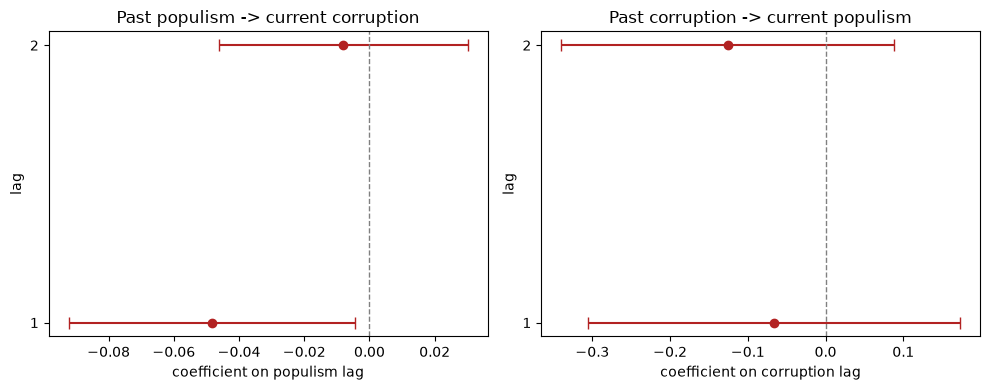

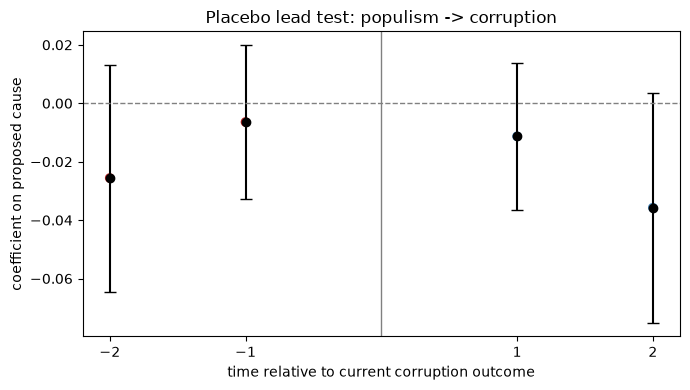

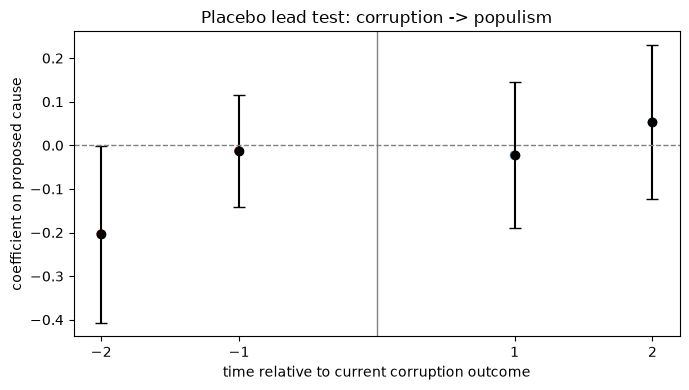

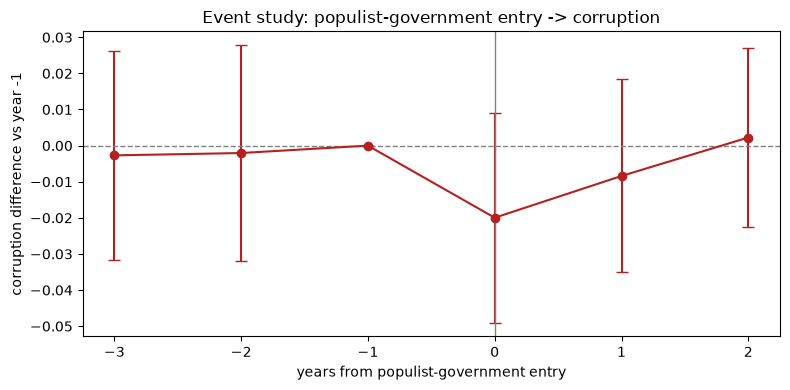

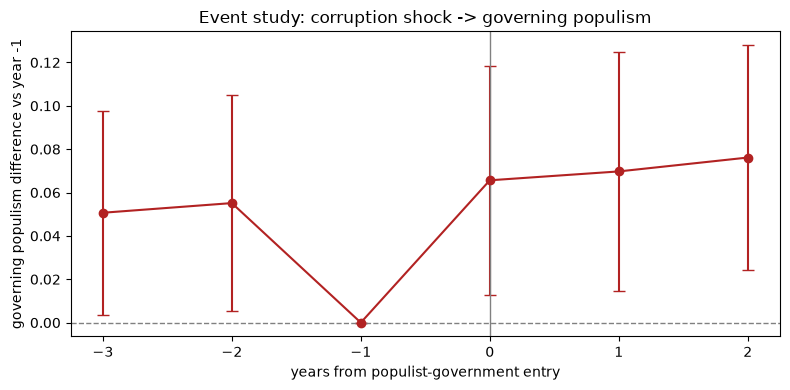

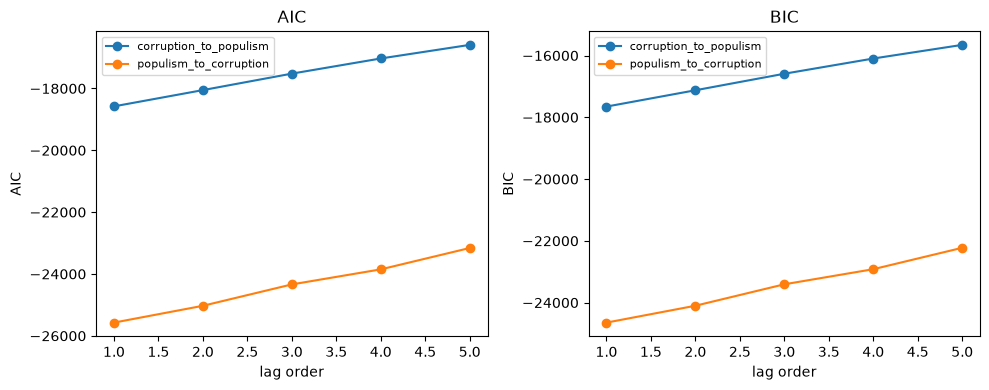

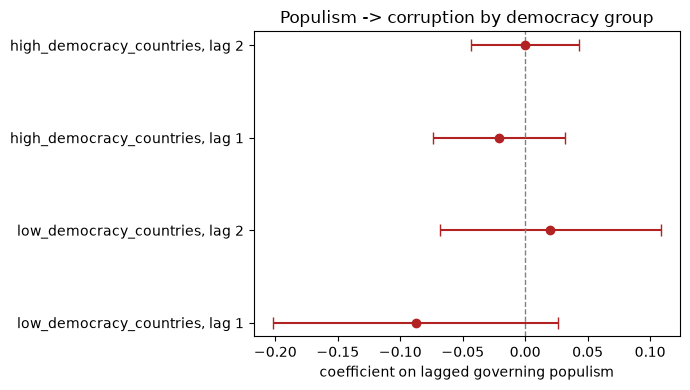

In [15]:
fig = coefficient_direction_plot(
    main_lead_lag,
    str(FIGURE_DIR / "fig4_causal_direction_coefficients.png"),
)
plt.show()

fig = placebo_lead_plot(
    placebo_pop_to_corr,
    str(FIGURE_DIR / "fig5_placebo_populism_to_corruption.png"),
    title="Placebo lead test: populism -> corruption",
)
plt.show()

fig = placebo_lead_plot(
    placebo_corr_to_pop,
    str(FIGURE_DIR / "fig6_placebo_corruption_to_populism.png"),
    title="Placebo lead test: corruption -> populism",
)
plt.show()

fig = event_study_plot(
    event_study_populist_entry,
    str(FIGURE_DIR / "fig7_event_study_populist_entry.png"),
    title="Event study: populist-government entry -> corruption",
    ylabel="corruption difference vs year -1",
)
plt.show()

fig = event_study_plot(
    event_study_corruption_shock,
    str(FIGURE_DIR / "fig8_event_study_corruption_shock.png"),
    title="Event study: corruption shock -> governing populism",
    ylabel="governing populism difference vs year -1",
)
plt.show()

fig = lag_information_plot(
    lag_ic,
    str(FIGURE_DIR / "fig9_lag_information_criteria.png"),
)
plt.show()

fig = democracy_split_plot(
    democracy_split,
    str(FIGURE_DIR / "fig10_democracy_split_lags.png"),
)
plt.show()

## 13. Save report artifacts

In [16]:
def to_markdown_table(frame: pd.DataFrame) -> str:
    display_frame = frame.copy()
    for col in display_frame.select_dtypes(include="number").columns:
        display_frame[col] = display_frame[col].round(4)
    display_frame = display_frame.fillna("")
    headers = [str(col) for col in display_frame.columns]
    lines = [
        "| " + " | ".join(headers) + " |",
        "| " + " | ".join(["---"] * len(headers)) + " |",
    ]
    for _, row in display_frame.iterrows():
        values = [str(row[col]).replace("|", "/") for col in display_frame.columns]
        lines.append("| " + " | ".join(values) + " |")
    return "\n".join(lines)

# Remove stale outputs from older versions before saving the current analytical tables.
for old_file in TABLE_DIR.glob("table*.csv"):
    old_file.unlink()
for old_file in TABLE_DIR.glob("table*.md"):
    old_file.unlink()

outputs = {
    "table1_lead_lag": lead_lag,
    "table2_granger": granger,
    "table3_placebo_populism_to_corruption": placebo_pop_to_corr,
    "table4_placebo_corruption_to_populism": placebo_corr_to_pop,
    "table5_event_study_populist_entry": event_study_populist_entry,
    "table6_event_study_corruption_shock": event_study_corruption_shock,
    "table7_electoral_sample_robustness": electoral_robustness,
    "table8_first_difference_direction": first_difference,
    "table9_lag_information_criteria": lag_ic,
    "table10_democracy_interaction_marginal": democracy_marginal,
    "table11_democracy_split_robustness": democracy_split,
}

for name, frame in outputs.items():
    frame.to_csv(TABLE_DIR / f"{name}.csv", index=False)
    (TABLE_DIR / f"{name}.md").write_text(to_markdown_table(frame), encoding="utf-8")

sorted(p.name for p in TABLE_DIR.glob("table*_*.csv"))

['table10_democracy_interaction_marginal.csv',
 'table11_democracy_split_robustness.csv',
 'table1_lead_lag.csv',
 'table2_granger.csv',
 'table3_placebo_populism_to_corruption.csv',
 'table4_placebo_corruption_to_populism.csv',
 'table5_event_study_populist_entry.csv',
 'table6_event_study_corruption_shock.csv',
 'table7_electoral_sample_robustness.csv',
 'table8_first_difference_direction.csv',
 'table9_lag_information_criteria.csv']

## 14. Report-ready interpretation

### Corruption -> populism

The reverse direction is tested with the same baseline lead-lag logic, the stricter Granger-style model, a placebo lead test, an event-study around corruption shocks, and first differences. The two-lag lead-lag model does not find statistically clear corruption lags. The Granger-style joint test also does not reject the null once governing populism's own persistence is included. The placebo test checks whether future corruption predicts current populism. The corruption-shock event-study has a post-event signal, but governing populism is already elevated before the shock, so it should be read cautiously as contextual clustering around the same episodes rather than clean causal evidence that corruption shocks produce later populist government.

### Populism -> corruption

The original direction is tested with lead-lag models, Granger-style models, placebo leads, an event-study around populist-government entry, forward-fill robustness, first differences, lag-window diagnostics, and democracy heterogeneity. The simple lead-lag model gives a negative one-year coefficient, but the stricter Granger-style model does not confirm that past populism predicts corruption beyond corruption's own persistence. The AIC/BIC lag checks are approximate diagnostics with shrinking samples, so they are useful context but not decisive lag-selection evidence.

### Overall conclusion

The strengthened pipeline does not provide robust evidence for either temporal direction. We do not find clear evidence that governing populism is followed by higher overall political corruption, nor that higher corruption is followed by higher governing populism. The safest report statement is that the panel evidence shows no robust temporal direction in the estimated specifications, with especially little support for the hypothesised positive populism-to-corruption channel.